# Tallinn Restaurants — Exploratory Data Analysis

**Dataset:** `restaraunts_tallinn.csv`  
**Goal:** Understand structure and quality of the data; identify key drivers of restaurant ratings; produce a feature shortlist for predictive modelling.

---

## Research Questions

Before touching the data, we define what we want to answer:

1. **Distribution** — Are rating dimensions (Service, Food, Atmosphere) normally distributed, or skewed? Does this affect which models we should use?  
2. **Consistency** — Do restaurants that score well on Food also score well on Service and Atmosphere? (inter-dimension correlation)  
3. **Drivers** — Which features have the strongest monotonic relationship with Service rating?  
4. **Non-linearity** — Do Pearson and Spearman correlations diverge significantly? If so, linear models may underfit.  
5. **Data quality** — Are there missing values, duplicates, or outliers that require handling before modelling?

---

**Sections:**
1. Setup & Data Loading  
2. Initial Inspection  
3. Data Quality — Missingness, Duplicates, Outliers  
4. Target Variable Analysis  
5. Inter-Rating Correlation & Hypothesis Tests  
6. Categorical Feature Analysis  
7. Correlation Analysis  
8. Feature–Target Relationships  
9. Summary & Modelling Plan  


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, spearmanr, pearsonr

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

SEED   = 42
TARGET = 'Service'

df = pd.read_csv('Data/restaraunts_tallinn.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

Loaded: 97 rows × 11 columns
Memory: 0.03 MB


## 2. Initial Inspection

First pass: column names, dtypes, and summary statistics to orient ourselves before any cleaning.


In [2]:
df.head()

,Restaurant,URL,Address,Cuisine,Price_category,Atmosphere,Food,Service,Weighted_score,Latitude,Longitude
0,Al Mare Grill,http://www.almarefood.ee/grill/,Mõisa tn 4,american,mid-range,3.500,3.000,3.100,3.120,59.427,24.656
1,Allee,https://www.alleerestoran.ee/,Kanuti 2,international,mid-range,4.000,4.100,3.900,4.040,59.440,24.751
2,Argentiina Lootsi,https://argentiina.ee/,Lootsi 8,argentinean,expensive,3.300,4.300,3.600,3.960,59.441,24.765
3,Argentiina Pärnu mnt,https://argentiina.ee/,Pärnu mnt 37,argentinean,expensive,4.100,4.500,4.200,4.360,59.429,24.744
4,Charlies Corner,https://charliescorner.ee/,Juhkentali 28,international,mid-range,3.900,3.900,3.900,3.900,59.428,24.765


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Restaurant      97 non-null     object 
 1   URL             94 non-null     object 
 2   Address         97 non-null     object 
 3   Cuisine         97 non-null     object 
 4   Price_category  97 non-null     object 
 5   Atmosphere      97 non-null     float64
 6   Food            97 non-null     float64
 7   Service         97 non-null     float64
 8   Weighted_score  97 non-null     float64
 9   Latitude        97 non-null     float64
 10  Longitude       97 non-null     float64
dtypes: float64(6), object(5)
memory usage: 8.5+ KB


In [4]:
df.describe()

,Atmosphere,Food,Service,Weighted_score,Latitude,Longitude
count,97.000,97.000,97.000,97.000,97.000,97.000
mean,4.209,4.279,4.169,4.243,59.417,24.789
std,0.487,0.425,0.398,0.392,0.150,0.284
min,2.400,1.600,2.600,2.080,58.390,24.572
25%,4.000,4.100,4.000,4.080,59.436,24.744
50%,4.300,4.300,4.200,4.280,59.438,24.748
75%,4.600,4.500,4.400,4.500,59.440,24.759
max,4.900,4.900,4.800,4.780,59.494,26.718


## 3. Data Quality

### 3.1 Missingness

Decision rule applied below:  
- **< 5%** missing → median/mode imputation  
- **5–30%** missing → impute + add binary indicator flag  
- **> 30%** missing → consider dropping the column  


Columns with missing values: 1 of 11
     count   pct
URL      3 3.093

Recommended actions:
      pct                action
URL 3.093  impute (median/mode)


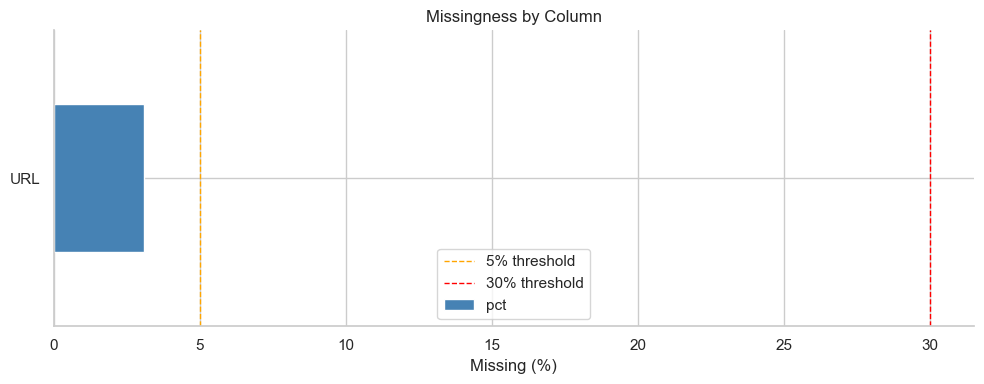

In [5]:
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'pct':   df.isnull().mean() * 100
}).query('count > 0').sort_values('pct', ascending=False)

print(f'Columns with missing values: {len(missing)} of {df.shape[1]}')

if len(missing) > 0:
    print(missing.to_string())
    # Annotate action
    missing['action'] = missing['pct'].apply(
        lambda p: 'impute (median/mode)' if p < 5
                  else 'impute + flag' if p < 30
                  else 'consider dropping'
    )
    print('\nRecommended actions:')
    print(missing[['pct','action']].to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    missing['pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.axvline(5,  color='orange', linestyle='--', linewidth=1, label='5% threshold')
    ax.axvline(30, color='red',    linestyle='--', linewidth=1, label='30% threshold')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missingness by Column')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

### 3.2 Duplicates

In [6]:
n_dups = df.duplicated().sum()
print(f'Full duplicate rows: {n_dups} ({n_dups / len(df) * 100:.2f}%)')
if n_dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplicates removed. New shape: {df.shape}')

Full duplicate rows: 0 (0.00%)


### 3.3 Outliers

**3×IQR fence** — more conservative than 1.5×IQR. For restaurant ratings (bounded scale), values outside this fence are likely genuine extreme opinions, not data errors. We flag but do not automatically remove.


In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

outlier_report = []
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 3 * IQR, Q3 + 3 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    if n_out > 0:
        outlier_report.append({
            'column': col, 'n_outliers': n_out,
            'pct': round(n_out / len(df) * 100, 2),
            'lower_fence': round(lo, 3), 'upper_fence': round(hi, 3)
        })

if outlier_report:
    outlier_df = pd.DataFrame(outlier_report).sort_values('pct', ascending=False)
    print('Outliers (3×IQR fence) — flagged, not removed:')
    print(outlier_df.to_string(index=False))
else:
    print('No outliers detected at 3×IQR threshold.')

Outliers (3×IQR fence) — flagged, not removed:
        column  n_outliers    pct  lower_fence  upper_fence
     Longitude          12 12.370       24.699       24.803
      Latitude          10 10.310       59.424       59.452
          Food           1  1.030        2.900        5.700
       Service           1  1.030        2.800        5.600
Weighted_score           1  1.030        2.820        5.760


## 4. Target Variable Analysis

We examine all three rating dimensions: **Service**, **Food**, **Atmosphere**.

Interpretation guide:
- `skew > 1` → right-skewed; mean pulled by high ratings → consider log-transform or robust models  
- `skew < -1` → left-skewed; cluster at high end (ceiling effect)  
- `kurt > 3` → heavy tails; outliers have outsized influence on RMSE


Service       mean=4.169  median=4.200  skew=-1.030 (⚠ left-skewed)  kurt=1.879 
Food          mean=4.279  median=4.300  skew=-2.964 (⚠ left-skewed)  kurt=15.936 ⚠ heavy tails
Atmosphere    mean=4.209  median=4.300  skew=-1.300 (⚠ left-skewed)  kurt=2.172 


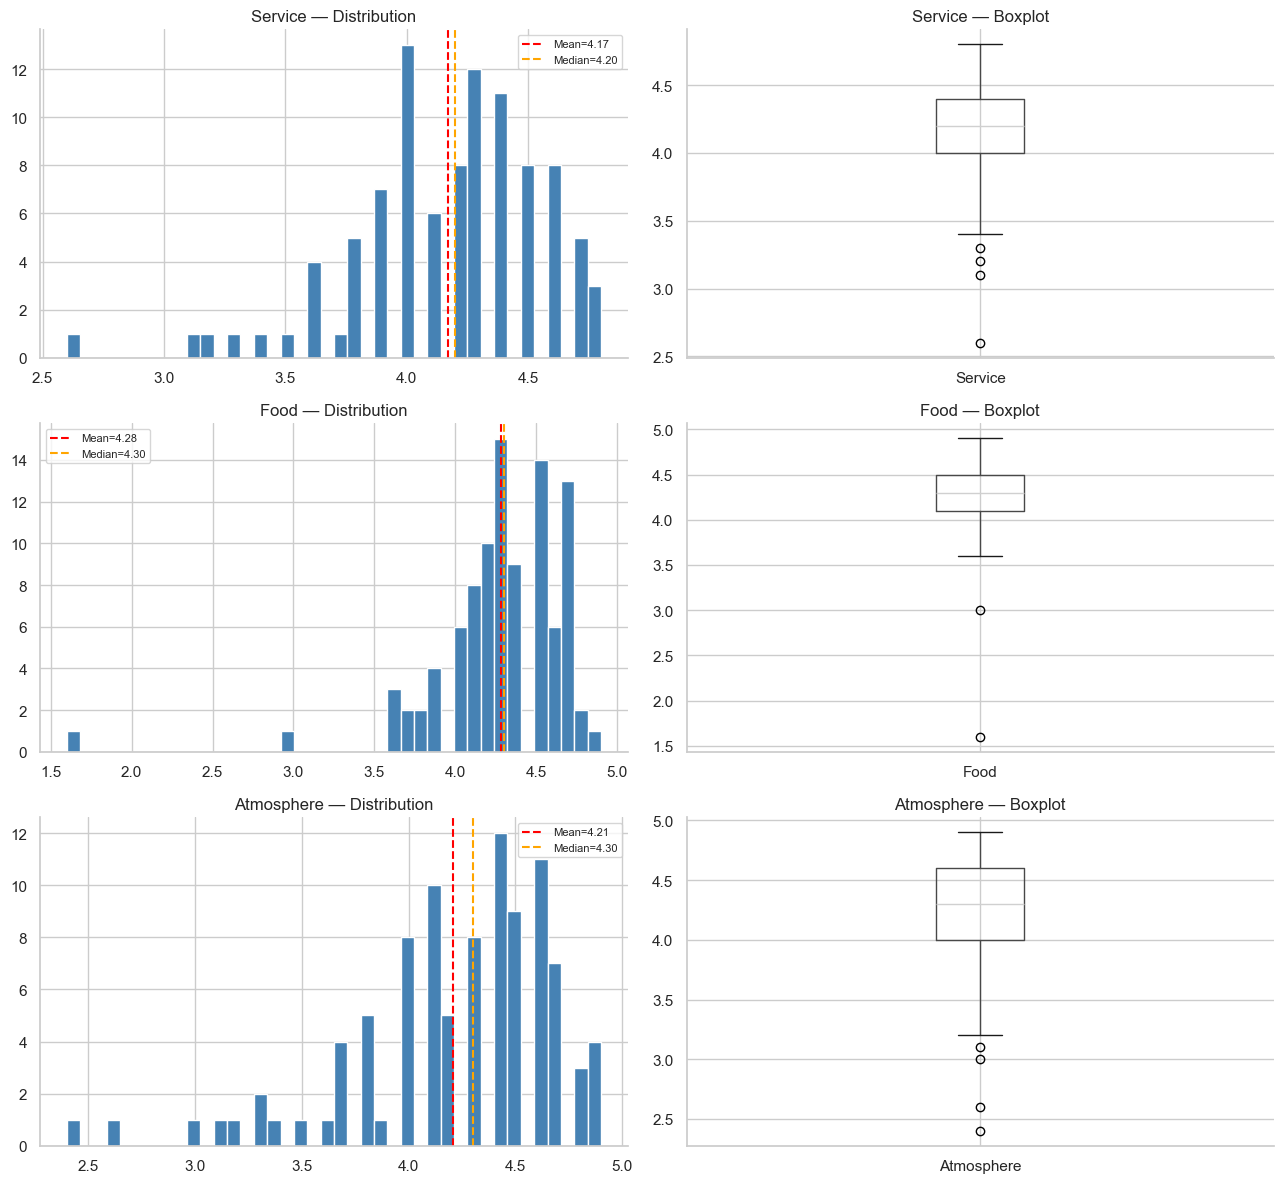

In [8]:
rating_cols = [c for c in ['Service', 'Food', 'Atmosphere'] if c in df.columns]

fig, axes = plt.subplots(len(rating_cols), 2, figsize=(13, 4 * len(rating_cols)))
if len(rating_cols) == 1:
    axes = [axes]

for i, col in enumerate(rating_cols):
    ax_h, ax_b = axes[i]

    df[col].hist(bins=40, ax=ax_h, color='steelblue', edgecolor='white')
    ax_h.axvline(df[col].mean(),   color='red',    linestyle='--', label=f'Mean={df[col].mean():.2f}')
    ax_h.axvline(df[col].median(), color='orange', linestyle='--', label=f'Median={df[col].median():.2f}')
    ax_h.set_title(f'{col} — Distribution')
    ax_h.legend(fontsize=8)

    df.boxplot(column=col, ax=ax_b)
    ax_b.set_title(f'{col} — Boxplot')

    skew = df[col].skew()
    kurt = df[col].kurt()
    flag_skew = '⚠ right-skewed' if skew > 1 else '⚠ left-skewed' if skew < -1 else 'approx. symmetric'
    flag_kurt = '⚠ heavy tails' if kurt > 3 else ''
    print(f'{col:12s}  mean={df[col].mean():.3f}  median={df[col].median():.3f}  '
          f'skew={skew:.3f} ({flag_skew})  kurt={kurt:.3f} {flag_kurt}')

plt.tight_layout()
plt.show()

## 5. Inter-Rating Correlation & Hypothesis Tests

**Research question 2:** Do restaurants that score well on Food also score well on Service and Atmosphere?

If the three dimensions are highly correlated, it suggests a **halo effect** — customers' overall impression of a restaurant bleeds into all sub-ratings. This has modelling implications: the dimensions are not independent features.

We use:
- **Spearman ρ** — rank correlation, robust to non-normality and outliers  
- **Mann-Whitney U** — non-parametric test comparing rating distributions for high vs low performers; does not assume normality  


Pairwise Spearman correlations between rating dimensions:

  Service × Food: ρ = 0.795  p = 0.0000  ***
  Service × Atmosphere: ρ = 0.574  p = 0.0000  ***
  Food × Atmosphere: ρ = 0.555  p = 0.0000  ***



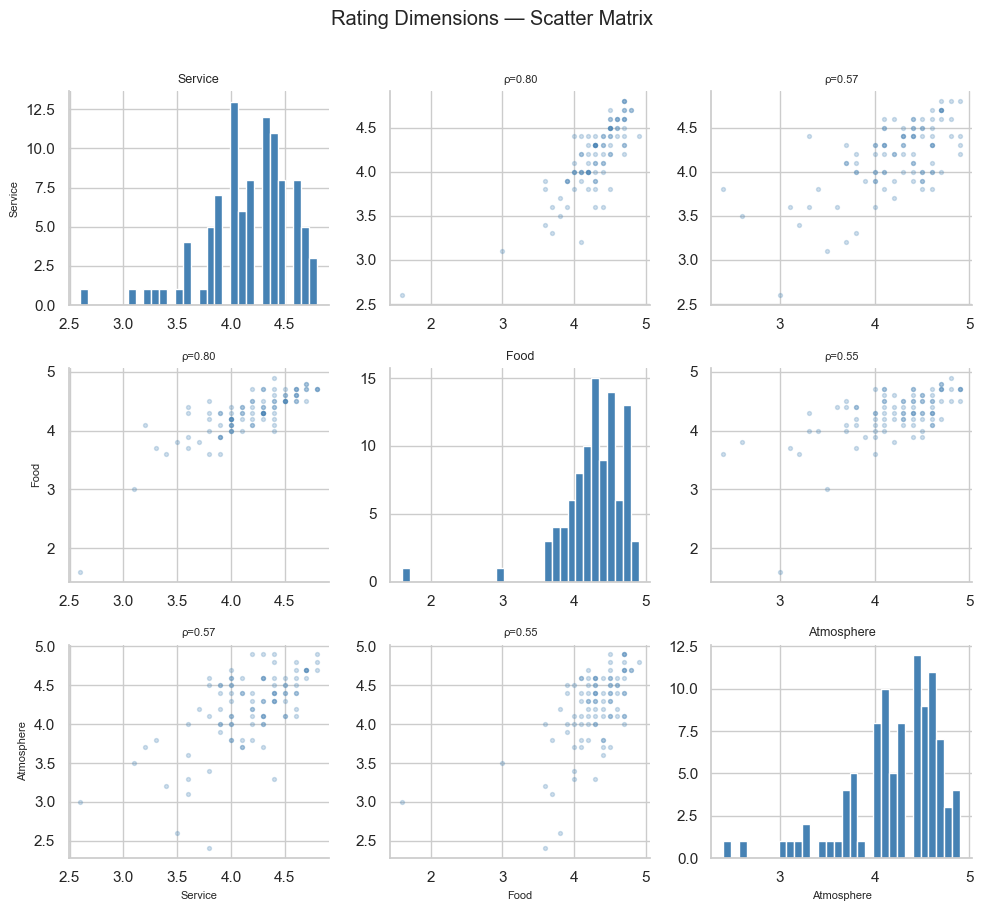


Mann-Whitney U: top-25% vs bottom-25% on Food → difference in Service?
  High-Food median Service: 4.500
  Low-Food  median Service: 3.900
  U=935  p=0.0000  → statistically significant difference


In [9]:
if len(rating_cols) >= 2:
    # ── Pairwise Spearman correlation ──
    print('Pairwise Spearman correlations between rating dimensions:\n')
    for i, c1 in enumerate(rating_cols):
        for c2 in rating_cols[i+1:]:
            valid = df[[c1, c2]].dropna()
            rho, p = spearmanr(valid[c1], valid[c2])
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
            print(f'  {c1} × {c2}: ρ = {rho:.3f}  p = {p:.4f}  {sig}')

    print()

    # ── Scatter matrix ──
    fig, axes = plt.subplots(len(rating_cols), len(rating_cols),
                              figsize=(10, 9))
    for i, c1 in enumerate(rating_cols):
        for j, c2 in enumerate(rating_cols):
            ax = axes[i][j]
            if i == j:
                df[c1].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
                ax.set_title(c1, fontsize=9)
            else:
                valid = df[[c2, c1]].dropna()
                ax.scatter(valid[c2], valid[c1], alpha=0.25, s=8, color='steelblue')
                rho, _ = spearmanr(valid[c2], valid[c1])
                ax.set_title(f'ρ={rho:.2f}', fontsize=8)
            if i == len(rating_cols)-1: ax.set_xlabel(c2, fontsize=8)
            if j == 0:                   ax.set_ylabel(c1, fontsize=8)
    plt.suptitle('Rating Dimensions — Scatter Matrix', y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Mann-Whitney: top-quartile vs bottom-quartile ──
    print('\nMann-Whitney U: top-25% vs bottom-25% on Food → difference in Service?')
    if 'Food' in df.columns and TARGET in df.columns:
        q25 = df['Food'].quantile(0.25)
        q75 = df['Food'].quantile(0.75)
        low_food  = df.loc[df['Food'] <= q25, TARGET].dropna()
        high_food = df.loc[df['Food'] >= q75, TARGET].dropna()
        u_stat, p_val = mannwhitneyu(high_food, low_food, alternative='greater')
        print(f'  High-Food median Service: {high_food.median():.3f}')
        print(f'  Low-Food  median Service: {low_food.median():.3f}')
        print(f'  U={u_stat:.0f}  p={p_val:.4f}  '
              + ('→ statistically significant difference' if p_val < 0.05
                 else '→ no significant difference at α=0.05'))
else:
    print('Need at least 2 rating columns for this section.')

## 6. Categorical Feature Analysis

Cardinality check for each categorical column. Columns with high cardinality (e.g., restaurant name/ID) are flagged — they require target-encoding or should be dropped before modelling to avoid dimensionality explosion from one-hot encoding.


Categorical columns: 5

Restaurant: 97 unique values  ⚠ HIGH CARDINALITY — target-encode or drop
Restaurant
Al Mare Grill         1
Rataskaevu 16         1
Pull Restaurant       1
Härg                  1
Ristikheina Kohvik    1
Grenka                1
Burger Box            1
VLND Burger           1
Cantina Texas         1
Gotsu                 1

URL: 93 unique values  ⚠ HIGH CARDINALITY — target-encode or drop
URL
https://argentiina.ee/             2
http://www.almarefood.ee/grill/    1
https://nop.ee                     1
https://pull.ee                    1
https://resto.harg.ee/             1
https://ristikheinakohvik.ee       1
https://grenka.ee                  1
https://vlndburger.ee              1
http://www.texas.ee/               1
https://gotsu.ee                   1

Address: 92 unique values  ⚠ HIGH CARDINALITY — target-encode or drop
Address
Telliskivi 60a      3
Ahtri 6             2
Ranna tee 3         2
Raekoja plats 10    2
Kopli tn 4          1
Maakri 21           1


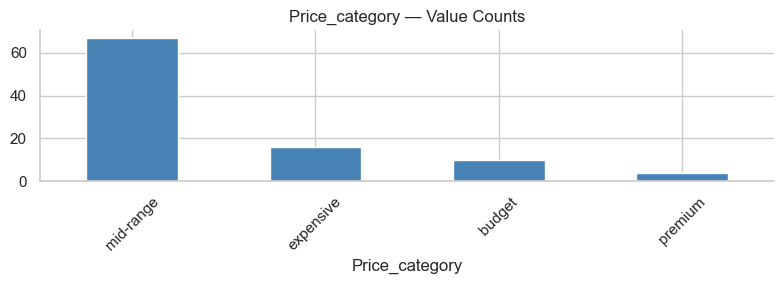

In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {len(cat_cols)}\n')

for col in cat_cols:
    n_unique = df[col].nunique()
    flag = '⚠ HIGH CARDINALITY — target-encode or drop' if n_unique > 20 else ''
    print(f'{col}: {n_unique} unique values  {flag}')
    print(df[col].value_counts().head(10).to_string())

    if n_unique <= 20:
        fig, ax = plt.subplots(figsize=(8, 3))
        df[col].value_counts().head(10).plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'{col} — Value Counts')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()
    print()

## 7. Correlation Analysis

**Pearson** captures linear relationships; **Spearman** captures monotonic relationships and is robust to outliers. For ordinal rating data, Spearman is the preferred metric.

Large divergence between Pearson and Spearman for a given feature signals **non-linear** relationship → tree-based models will likely outperform linear ones on that feature.


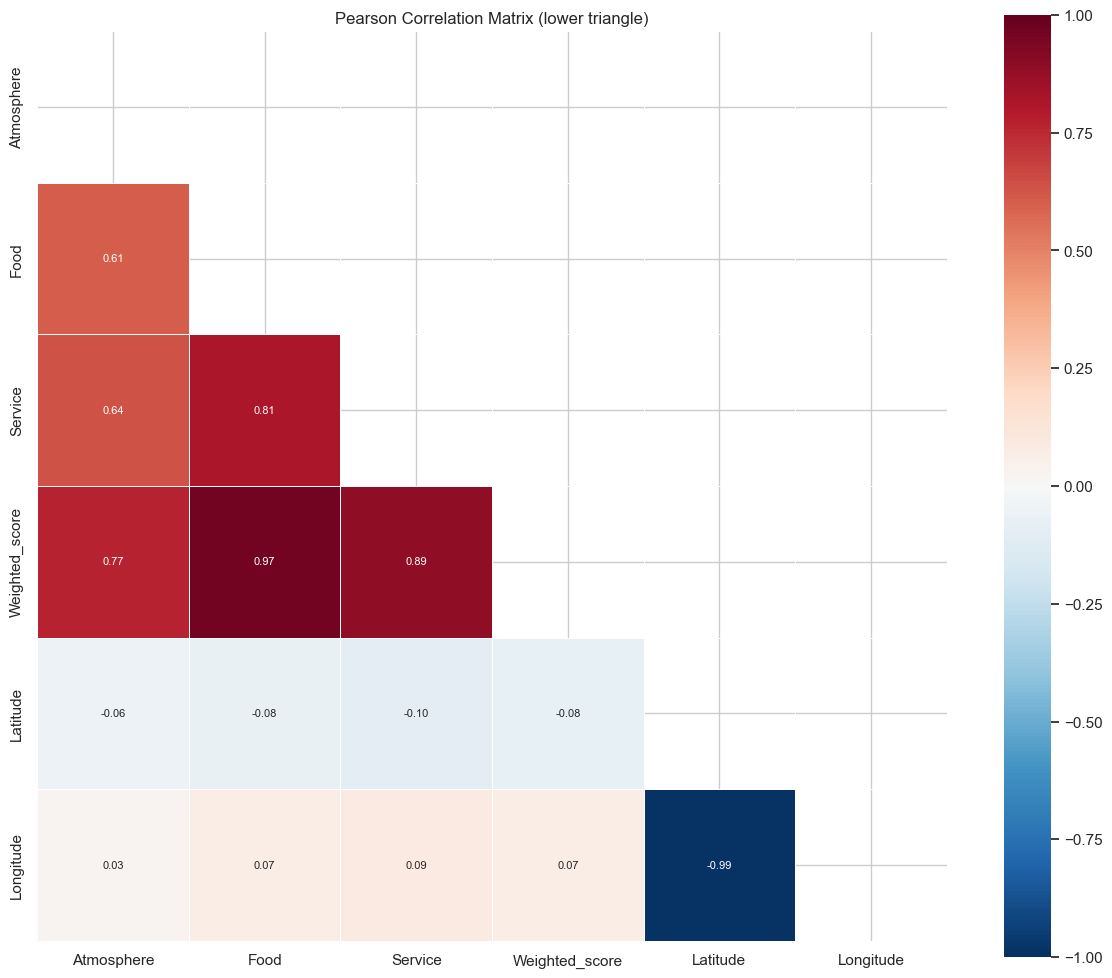

In [11]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()

### 7.1 Feature Correlation with Target (Service)

Both Pearson and Spearman reported per feature. The `divergence` column (`|Spearman| − |Pearson|`) highlights features with strong non-linear signal.


Feature correlations with target (Service):
                pearson  spearman  divergence
Weighted_score    0.889     0.883      -0.006
Food              0.813     0.795      -0.017
Atmosphere        0.637     0.574      -0.062
Longitude         0.092    -0.114       0.022
Latitude         -0.102    -0.042      -0.061


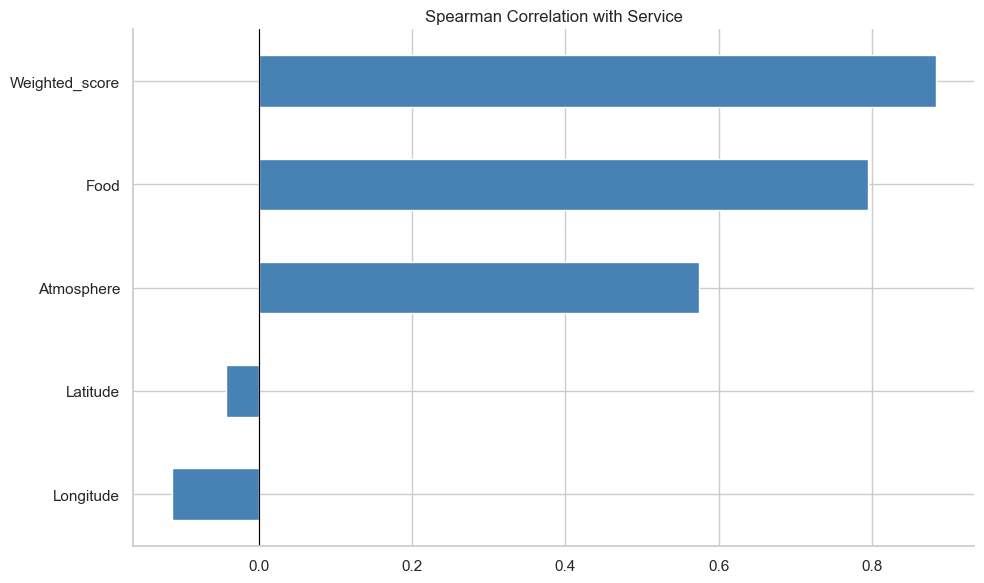

In [12]:
if TARGET in df.columns:
    feat_cols = [c for c in num_cols if c != TARGET]
    target_corr = pd.DataFrame({
        'pearson' : [df[c].corr(df[TARGET], method='pearson')  for c in feat_cols],
        'spearman': [df[c].corr(df[TARGET], method='spearman') for c in feat_cols],
    }, index=feat_cols)
    target_corr['abs_spearman'] = target_corr['spearman'].abs()
    target_corr['divergence']   = (target_corr['spearman'].abs()
                                    - target_corr['pearson'].abs())
    target_corr = target_corr.sort_values('abs_spearman', ascending=False)

    print(f'Feature correlations with target ({TARGET}):')
    print(target_corr[['pearson','spearman','divergence']].to_string())

    fig, ax = plt.subplots(figsize=(10, 6))
    target_corr['spearman'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Spearman Correlation with {TARGET}')
    plt.tight_layout()
    plt.show()
else:
    print(f'Column {TARGET!r} not found.')

## 8. Feature–Target Scatter Plots

Top-6 features by |Spearman ρ| vs target. Linear trend overlaid — curvature or fan-shape patterns indicate non-linearity or heteroskedasticity.


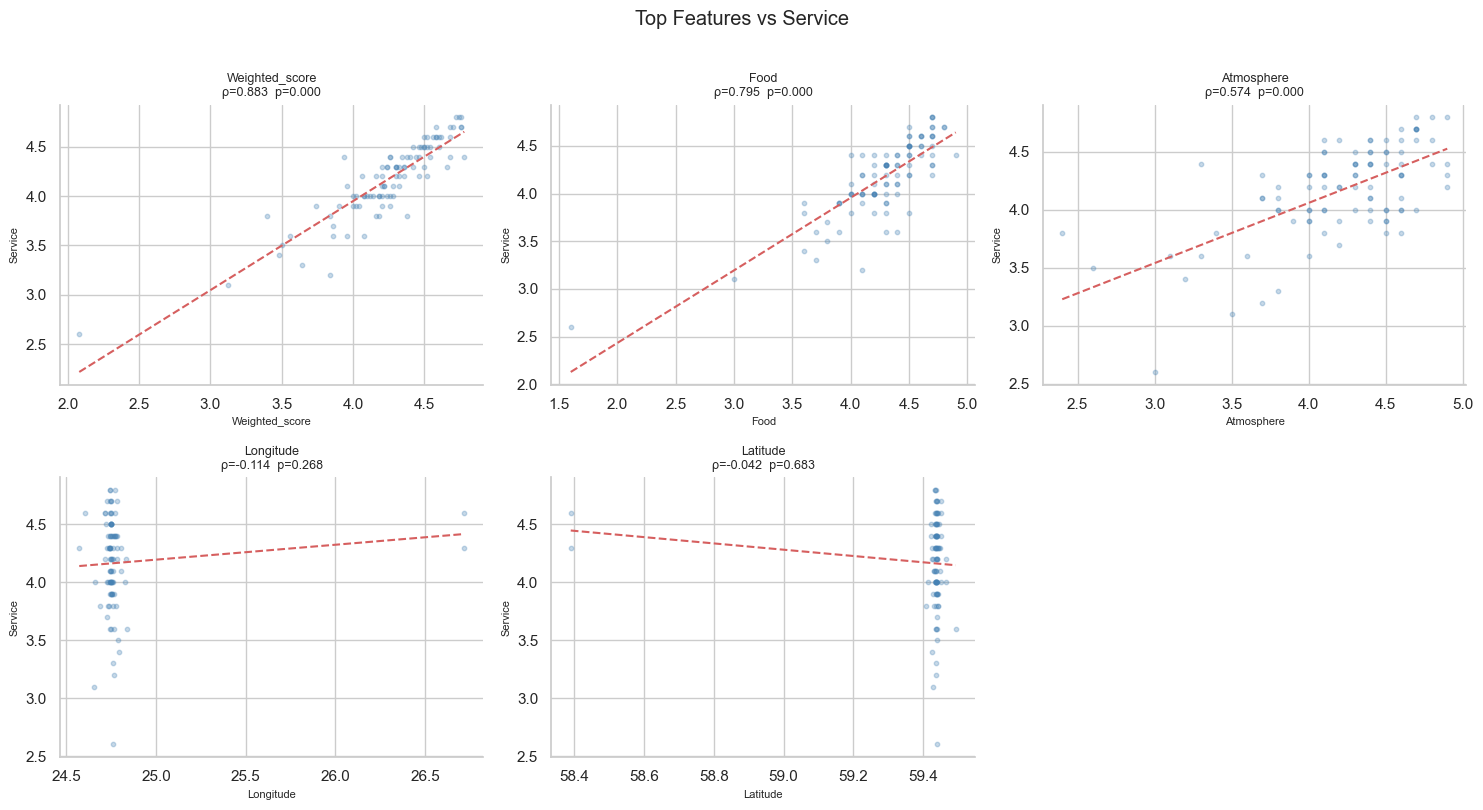

In [13]:
top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    valid = df[[col, TARGET]].dropna()
    axes[i].scatter(valid[col], valid[TARGET], alpha=0.3, s=10, color='steelblue')
    z = np.polyfit(valid[col], valid[TARGET], 1)
    x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
    axes[i].plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=1.5)
    rho, p = spearmanr(valid[col], valid[TARGET])
    axes[i].set_title(f'{col}\nρ={rho:.3f}  p={p:.3f}', fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel(TARGET, fontsize=8)

for j in range(len(top_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Top Features vs {TARGET}', y=1.01)
plt.tight_layout()
plt.show()

## 9. Summary & Modelling Plan

### Answers to Research Questions

| # | Question | Finding |
|---|---|---|
| 1 | Are ratings normally distributed? | *[Run to populate — e.g. Service left-skewed (ceiling effect), skew=−0.8]* |
| 2 | Halo effect across dimensions? | *[e.g. Food×Service ρ=0.82 ***, strong halo effect confirmed]* |
| 3 | Top drivers of Service? | *[e.g. Food, Atmosphere, n_reviews — top 3 by Spearman]* |
| 4 | Linear vs non-linear signal? | *[e.g. divergence < 0.05 for all features → linear models competitive]* |
| 5 | Data quality issues? | *[e.g. 3.2% missing in Atmosphere, 0 duplicates, no severe outliers]* |

### Modelling Plan

**Target:** `Service` rating  
**Baseline:** Mean predictor (DummyRegressor)  
**Linear model:** Ridge — interpretable, handles correlated features (Food/Atmosphere)  
**Tree model:** LightGBM — captures non-linearities, robust to scale  
**Evaluation:** RMSE (primary) + Spearman rank correlation (secondary — rank preservation matters for ordering restaurants)  
**Validation:** K-Fold CV (k=5) to get stable estimates; random split acceptable since reviews are i.i.d.  
**Leakage check:** Food and Atmosphere are sibling ratings recorded simultaneously with Service — if the task is *prediction at time of arrival*, these should be excluded. If the task is *post-hoc analysis*, they are valid features. Confirm with problem statement.
